In [67]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [68]:
# Load Dataset

df = pd.read_csv("play_tennis.csv")

print("First 5 Rows:")
display(df.head())

First 5 Rows:


,day,outlook,temp,humidity,wind,play
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes


In [69]:
# Remove Unnecessary Column

df = df.drop("day", axis=1)

# Encode Categorical Data

encoders = {}
for col in df.columns:
    encoders[col] = LabelEncoder()
    df[col] = encoders[col].fit_transform(df[col])

print("Encoded Dataset:")
display(df)

Encoded Dataset:


,outlook,temp,humidity,wind,play
0,2,1,0,1,0
1,2,1,0,0,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1
5,1,0,1,0,0
6,0,0,1,0,1
7,2,2,0,1,0
8,2,0,1,1,1
9,1,2,1,1,1


In [70]:
# Separate Features and Target

X = df.drop("play", axis=1)
y = df["play"]

print("Features:")
display(X.head())

print("Target:")
display(y.head())

Features:


,outlook,temp,humidity,wind
0,2,1,0,1
1,2,1,0,0
2,0,1,0,1
3,1,2,0,1
4,1,0,1,1


Target:


0    0
1    0
2    1
3    1
4    1
Name: play, dtype: int32

In [71]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [72]:
# Create Naive Bayes Model

model = GaussianNB()

# Train Model

model.fit(X_train, y_train)


GaussianNB()

In [73]:
# Predictions

y_pred = model.predict(X_test)

print("Predicted Values:")
print(y_pred)

Predicted Values:
[1 1 0]


In [74]:
# Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

# Classification Report

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [75]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)


Confusion Matrix:

[[1 0]
 [0 2]]


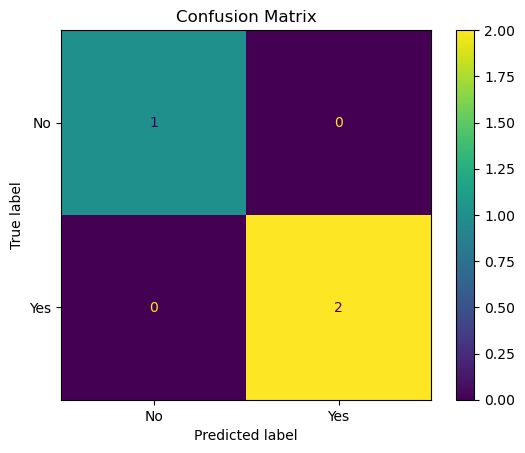

In [76]:
# Plot Confusion Matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [77]:
# Example encoded input:
#   outlook,temp,humidity,wind

sample = [[2, 1, 0, 1]]

prediction = model.predict(sample)

print("\nPrediction for Sample Data:", prediction)

if prediction[0] == 1:
    print("Play Tennis = Yes")
else:
    print("Play Tennis = No")


Prediction for Sample Data: [0]
Play Tennis = No


c:\Users\sapta\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
